In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())
from keras.models import Model
from keras.optimizers import Adam
from keras.layers import Convolution2D, GlobalAveragePooling2D, Dense, Input, concatenate
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import pandas as pd
import random
import ntpath

torch


In [2]:
data_dir = 'sim_data'
columns = ['left', 'center', 'right', 'mask', 'steering']
data = pd.read_csv(os.path.join(data_dir, 'driving_log.csv'), names=columns)
pd.set_option('display.max_colwidth', None)
data.head()

,left,center,right,mask,steering
0,left,center,right,mask,steering
1,driving_model/sim_data/RGB\left_00000.png,driving_model/sim_data/RGB\center_00000.png,driving_model/sim_data/RGB\right_00000.png,driving_model/sim_data/masks\00000.png,-0.0014077980304136872
2,driving_model/sim_data/RGB\left_00001.png,driving_model/sim_data/RGB\center_00001.png,driving_model/sim_data/RGB\right_00001.png,driving_model/sim_data/masks\00001.png,-0.0010198625968769193
3,driving_model/sim_data/RGB\left_00002.png,driving_model/sim_data/RGB\center_00002.png,driving_model/sim_data/RGB\right_00002.png,driving_model/sim_data/masks\00002.png,-0.0007661748677492142
4,driving_model/sim_data/RGB\left_00003.png,driving_model/sim_data/RGB\center_00003.png,driving_model/sim_data/RGB\right_00003.png,driving_model/sim_data/masks\00003.png,-0.0007147158030420542


In [3]:
def path_leaf(path):
    head, tail = ntpath.split(path)
    return tail
data['center'] = data['center'].apply(path_leaf)
data['left'] = data['left'].apply(path_leaf)
data['right'] = data['right'].apply(path_leaf)

data.head()

,left,center,right,mask,steering
0,left,center,right,mask,steering
1,left_00000.png,center_00000.png,right_00000.png,driving_model/sim_data/masks\00000.png,-0.0014077980304136872
2,left_00001.png,center_00001.png,right_00001.png,driving_model/sim_data/masks\00001.png,-0.0010198625968769193
3,left_00002.png,center_00002.png,right_00002.png,driving_model/sim_data/masks\00002.png,-0.0007661748677492142
4,left_00003.png,center_00003.png,right_00003.png,driving_model/sim_data/masks\00003.png,-0.0007147158030420542


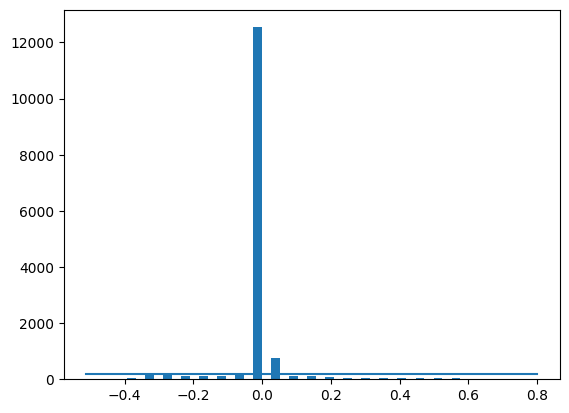

In [4]:
data['steering'] = pd.to_numeric(data['steering'], errors='coerce')
data = data.dropna(subset=['steering'])
num_bins = 25
samples_per_bin = 200
hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
plt.bar(center, hist, width=0.025)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

length of data 15000
removed 12879
remaining data 2121


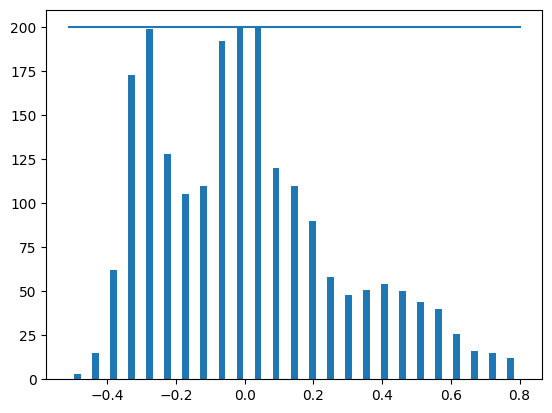

In [5]:
print(f"length of data {len(data)}")
remove_list = []

for j in range(num_bins):
    list_ = []
    for i in range(len(data['steering'])):
        if data['steering'].iloc[i] >= bins[j] and data['steering'].iloc[i] <= bins[j+1]:
            list_.append(i)
    list_ = shuffle(list_)
    list_ = list_[samples_per_bin:]
    remove_list.extend(list_)

print(f'removed {len(remove_list)}')
data.drop(data.index[remove_list], inplace=True)
print(f'remaining data {len(data)}')

hist, _ = np.histogram(data['steering'], (num_bins))
plt.bar(center, hist, width=0.02)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

In [6]:
print(data.iloc[1])
def load_img_steering(rgb_dir, df):
    rgb_path = []
    steering = []
    for i in range(len(data)):
        indexed_data = data.iloc[i]
        center, left, right = indexed_data[0], indexed_data[1], indexed_data[2]
        rgb_path.append(os.path.join(rgb_dir, center.strip()))
        steering.append(float(indexed_data[4]))
        rgb_path.append(os.path.join(rgb_dir, left.strip()))
        steering.append(float(indexed_data[4]) + 0.15)
        rgb_path.append(os.path.join(rgb_dir, right.strip()))
        steering.append(float(indexed_data[4]) - 0.15)
    rgb_paths = np.asarray(rgb_path)
    steerings = np.asarray(steering)

    return rgb_paths, steerings

rgb_paths, steerings = load_img_steering(data_dir + '/RGB', data)

left                                left_00060.png
center                            center_00060.png
right                              right_00060.png
mask        driving_model/sim_data/masks\00060.png
steering                                  0.025925
Name: 61, dtype: object


C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_30996\3371145471.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center, left, right = indexed_data[0], indexed_data[1], indexed_data[2]
C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_30996\3371145471.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  steering.append(float(indexed_data[4]))
C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_30996\3371145471.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

In [7]:
rgb_train, rgb_valid, steer_train, steer_valid = train_test_split(rgb_paths, steerings, test_size=0.2, random_state=6)
print(f"Training Samples: {len(rgb_train)}\nValid Samples: {len(rgb_valid)}")

Training Samples: 5090
Valid Samples: 1273


Text(0.5, 1.0, 'Validation Set')

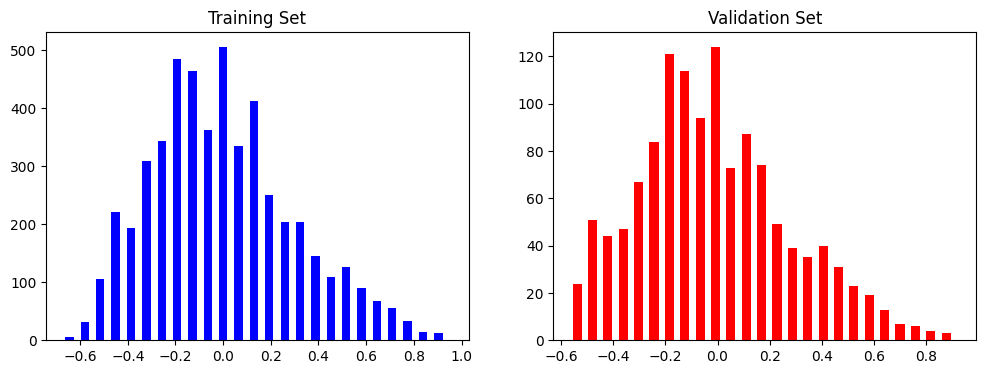

In [8]:
fix, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(steer_train, bins=num_bins, width=0.035, color='blue')
axes[0].set_title('Training Set')
axes[1].hist(steer_valid, bins=num_bins, width=0.035, color='red')
axes[1].set_title('Validation Set')

In [9]:
def zoom(img):
    zoom = A.Compose(
        [A.Affine(scale=(1.0, 1.3))]
    )
    augmented = zoom(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Zoomed Image')

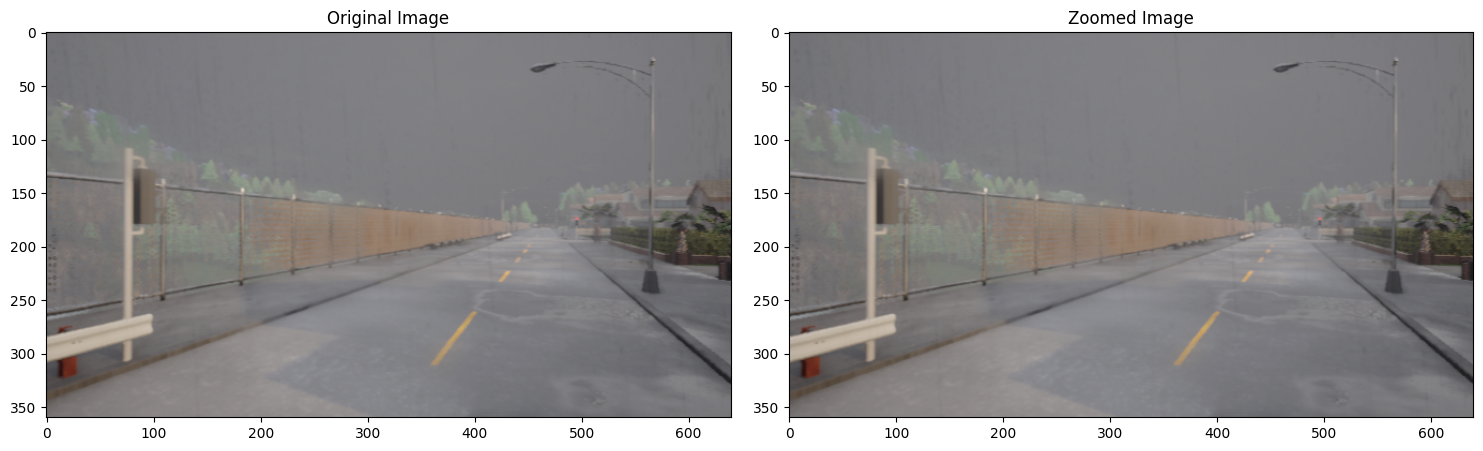

In [10]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)

zoomed_image = zoom(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(zoomed_image)
axes[1].set_title('Zoomed Image')

In [11]:
def pan(img):
    pan = A.Compose(
        [A.Affine(translate_percent={"x" : (-0.1, 0.1), "y" : (-0.1, 0.1)})]
    )
    augmented = pan(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Panned Image')

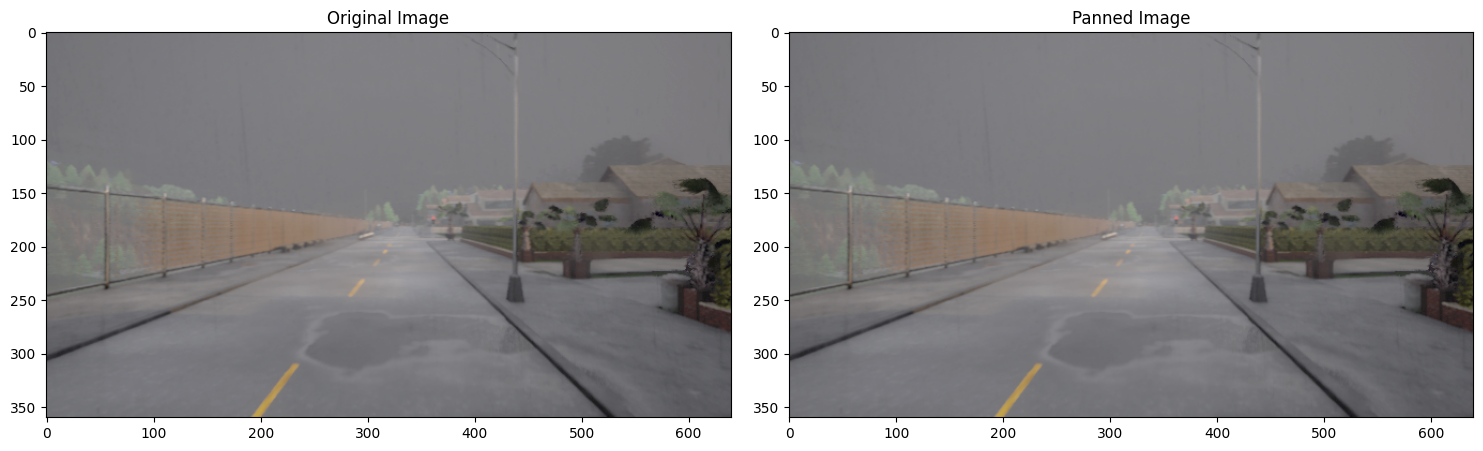

In [12]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)

panned_image = pan(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(panned_image)
axes[1].set_title('Panned Image')

In [13]:
def img_random_brightness(img):
    brightness = A.RandomBrightnessContrast(
    brightness_limit=0.2,
    contrast_limit=0.0,
    p=1.0)

    augmented = brightness(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Brightness Altered Image')

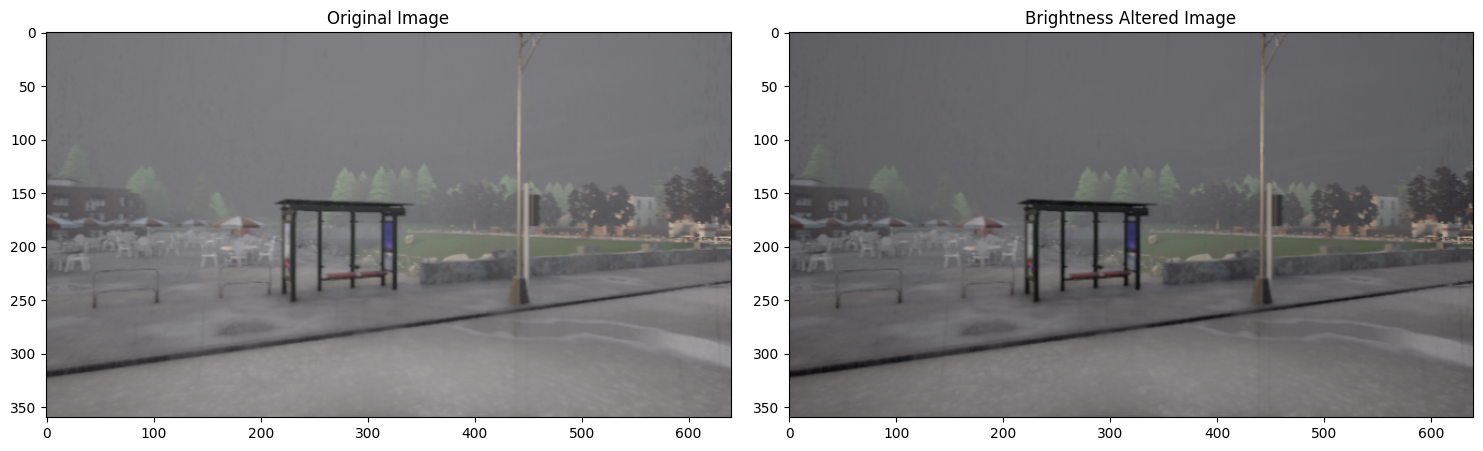

In [14]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)
brightness_altered_img = img_random_brightness(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(brightness_altered_img)
axes[1].set_title('Brightness Altered Image')

In [15]:
def img_random_flip(img, steering_angle):
    img = cv2.flip(img, 1)
    steering_angle = -steering_angle
    return img, steering_angle

Text(0.5, 1.0, 'Flipped Image - Steering Angle: -0.7562840819358826')

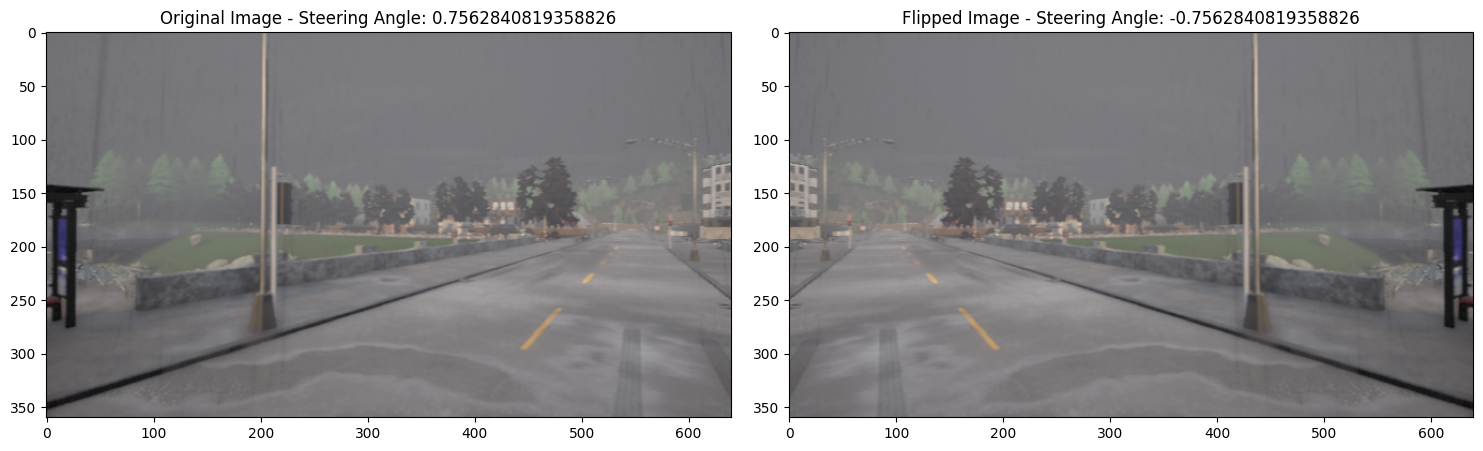

In [16]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
steering_angle = steerings[random_index]

original_image = mpimg.imread(image)

flipped_image, flipped_steering = img_random_flip(original_image, steering_angle)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image - Steering Angle: ' + str(steering_angle))
axes[1].imshow(flipped_image)
axes[1].set_title('Flipped Image - Steering Angle: ' + str(flipped_steering))

In [17]:
def random_augment(image, steering_angle):
    image = mpimg.imread(image)

    if np.random.rand() < 0.5:
        image = pan(image)

    if np.random.rand() < 0.5:
        image = zoom(image)
    
    if np.random.rand() < 0.5:
        image = img_random_brightness(image)
    
    if np.random.rand() < 0.5:
        image, steering_angle = img_random_flip(image, steering_angle)
    
    return image, steering_angle

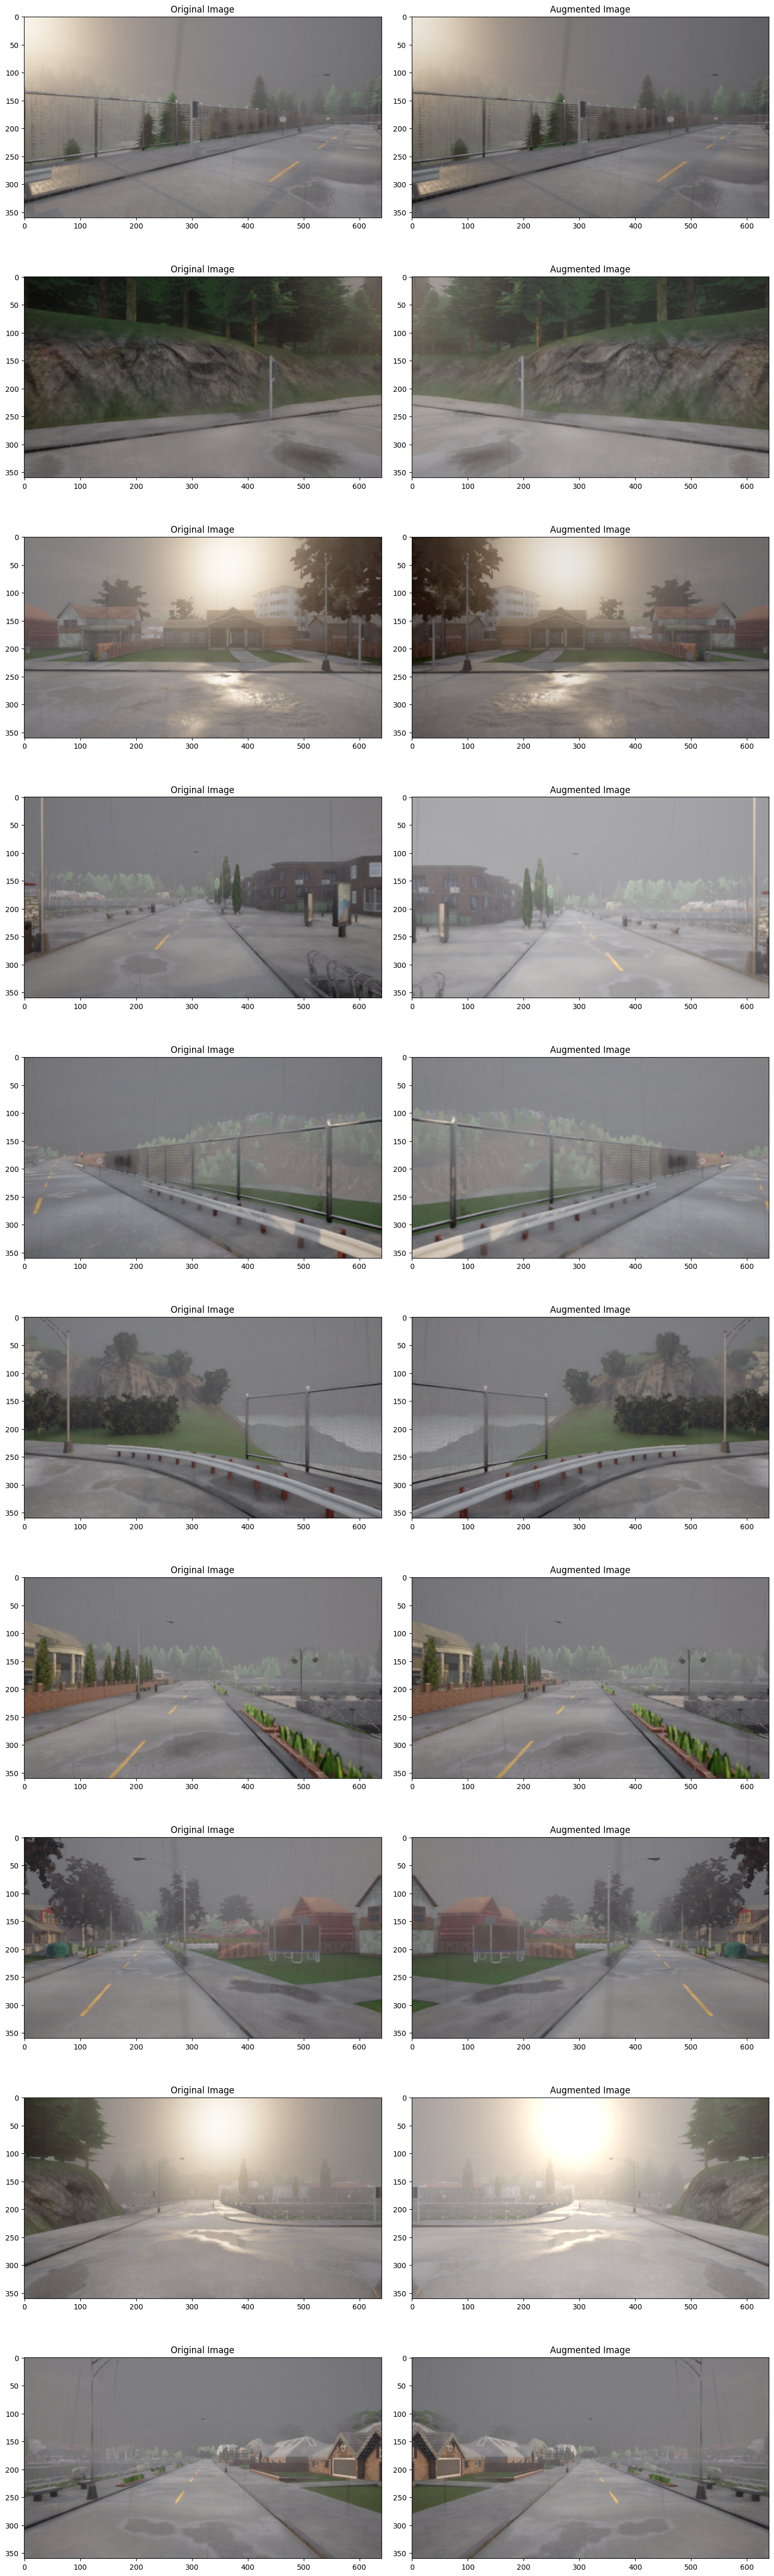

In [18]:
ncol = 2
nrow = 10

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 50))
fig.tight_layout()

for i in range(10):
    randnum = random.randint(0, len(rgb_paths) - 1)
    random_image = rgb_paths[randnum]
    random_steering = steerings[randnum]

    original_image = mpimg.imread(random_image)

    augmented_image, augmented_steering = random_augment(random_image, random_steering)

    axes[i][0].imshow(original_image)
    axes[i][0].set_title('Original Image')
    axes[i][1].imshow(augmented_image)
    axes[i][1].set_title('Augmented Image')

In [19]:
def img_preprocess(img, ):
    img = img[150:, :, :]
    img = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.resize(img, (200, 66))
    img = img.astype(np.float32) / 255.0

    return img

Text(0.5, 1.0, 'Preprocessed Image')

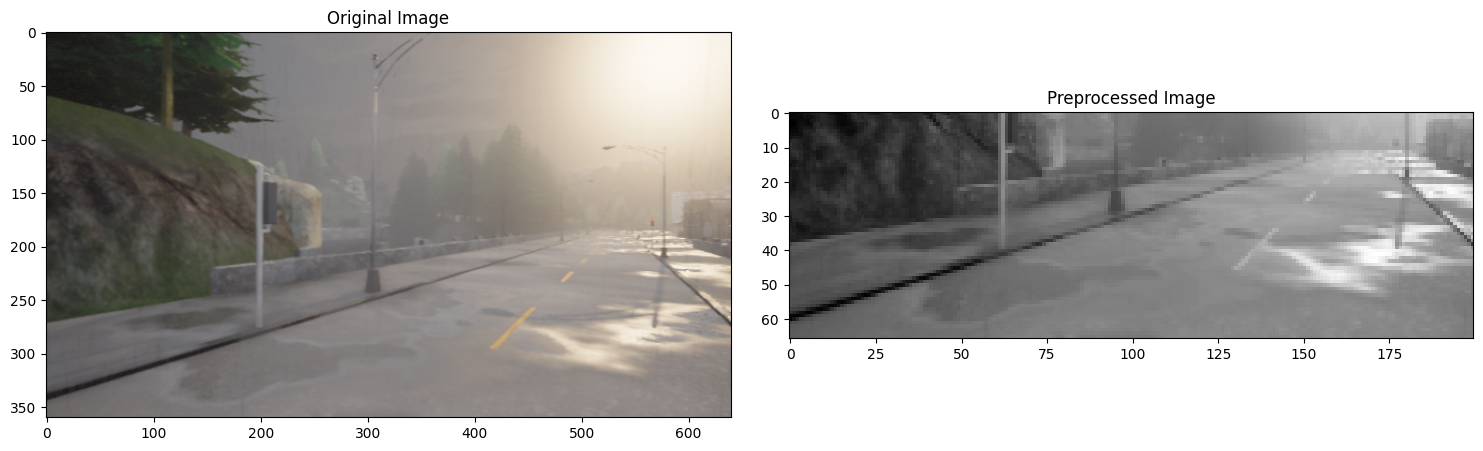

In [20]:
image = rgb_paths[100]
original_image = mpimg.imread(image)
preprocessed_image = img_preprocess(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(preprocessed_image[:, :, 0], cmap='gray')
axes[1].set_title('Preprocessed Image')

In [21]:
def batch_generator(image_paths, steering_angles, batch_size, istraining):
    while True:
        batch_img = []
        batch_steering = []

        for i in range(batch_size):
            random_index = random.randint(2, len(image_paths) - 1)

            imgs = []
            for k in [random_index-2, random_index-1, random_index]:
                if istraining:
                    img, _ = random_augment(image_paths[k], steering_angles[k])
                else:
                    img = mpimg.imread(image_paths[k])
                
                img = img_preprocess(img, )
                imgs.append(img)

            imgs = np.concatenate(imgs, axis=-1)

            batch_img.append(imgs)
            batch_steering.append(steering_angles[random_index])

        yield ([np.asarray(batch_img)], np.asarray(batch_steering))

Text(0.5, 1.0, 'Validation Image')

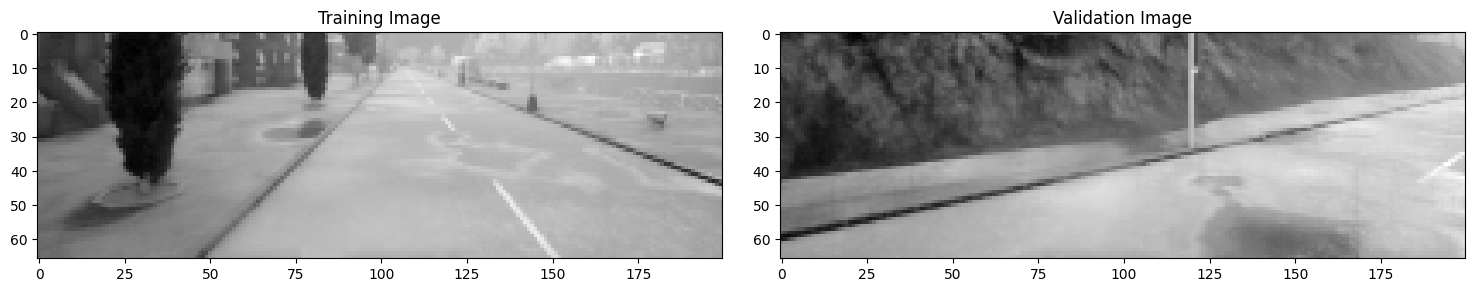

In [22]:
train_gen, steer_train_gen = next(batch_generator(rgb_train, steer_train, 1, 1))
valid_gen, steer_valid_gen = next(batch_generator(rgb_valid, steer_valid, 1, 0))

rgb_train_gen = train_gen[0]
rgb_valid_gen = valid_gen[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()

axes[0].imshow(rgb_train_gen[0][:, :, 0], cmap='gray')
axes[0].set_title('Training Image')
axes[1].imshow(rgb_valid_gen[0][:, :, 0], cmap='gray')
axes[1].set_title('Validation Image')

In [23]:
def steering_model():
  img_input = Input(shape=(66, 200, 9), name="img_input")

  x = Convolution2D(32, (5, 5), strides=(2, 2), activation='elu')(img_input)
  x = Convolution2D(64, (5, 5), strides=(2, 2), activation='elu')(x)
  x = Convolution2D(128, (3, 3), activation='elu')(x)
  x = Convolution2D(128, (3, 3), activation='elu')(x)

  x = Dense(100, activation='elu')(x)
  x = Dense(50, activation='elu')(x)
  x = Dense(10, activation='elu')(x)

  output = Dense(1, activation='tanh', name='steering_output')(x)

  model = Model(inputs=img_input, outputs=output)
  optimizer = Adam(learning_rate=1e-3)
  model.compile(loss='mse', optimizer=optimizer)

  return model


In [24]:
model = steering_model()
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img_input (InputLayer)          │ (None, 66, 200, 9)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 31, 98, 32)     │         7,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 47, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10, 43, 100)    │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10, 43, 50)     │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10, 43, 10)     │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ steering_output (Dense)         │ (None, 10, 43, 1)      │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,407 (1.14 MB)

 Trainable params: 298,407 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [25]:
history = model.fit(batch_generator(rgb_train, steer_train, batch_size=100, istraining=1), steps_per_epoch=300, epochs=10, validation_data=(batch_generator(rgb_valid, steer_valid, batch_size=100, istraining=0)), validation_steps=200, verbose=1, shuffle=1)

Epoch 1/10


c:\Users\Kanumuri\.conda\envs\keras\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: img_input
Received: inputs=['Tensor(shape=torch.Size([100, 66, 200, 9]))']
  warnings.warn(msg)


300/300 ━━━━━━━━━━━━━━━━━━━━ 1947s 7s/step - loss: 0.0886 - val_loss: 0.0841
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1890s 6s/step - loss: 0.0898 - val_loss: 0.0823
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1909s 6s/step - loss: 0.0894 - val_loss: 0.0828
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1898s 6s/step - loss: 0.0904 - val_loss: 0.0828
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1893s 6s/step - loss: 0.0891 - val_loss: 0.0833
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1906s 6s/step - loss: 0.0885 - val_loss: 0.0851
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1923s 6s/step - loss: 0.0895 - val_loss: 0.0844
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1901s 6s/step - loss: 0.4036 - val_loss: 1.0915
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1871s 6s/step - loss: 1.0698 - val_loss: 1.0904
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1844s 6s/step - loss: 1.0645 - val_loss: 1.0843


Text(0.5, 0, 'Epoch')

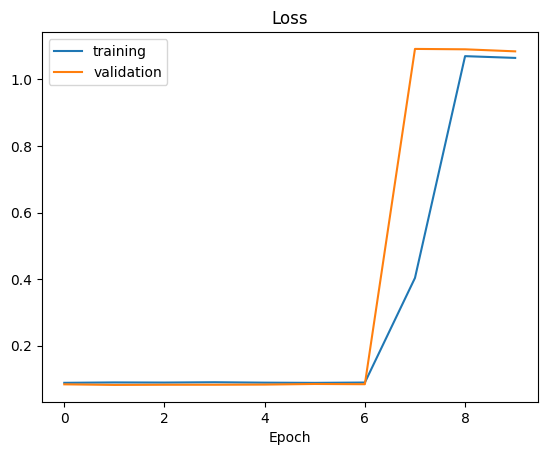

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'])
plt.title('Loss')
plt.xlabel('Epoch')

In [27]:
model.save('steering_model.h5')